In [1]:
#Load Final Dataset
import pandas as pd

df = pd.read_csv('fraud_predictions.csv')

print(df.shape)
df.head()

(6362620, 10)


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,transaction_frequency,velocity,isFraud,ai_fraud_flag,anomaly_score
0,244486.46,8946.00,0.00,526950.37,771436.84,1,999.0,0,0,0.411647
1,3170.28,58089.00,54918.72,0.00,0.00,1,999.0,0,0,0.433367
2,8424.74,783.00,0.00,0.00,0.00,1,999.0,0,0,0.439038
3,261877.19,7596.00,269473.19,1126627.70,864750.51,1,999.0,0,0,0.385170
4,20528.65,2302074.12,2322602.77,82696.17,62167.52,1,999.0,0,0,0.302614


In [2]:
#Calculate Final KPIs
total_transactions = len(df)

fraud_transactions = df['isFraud'].sum()

fraud_percentage = (
    fraud_transactions / total_transactions
) * 100

ai_flagged = df['ai_fraud_flag'].sum()

print("Total Transactions:", total_transactions)
print("Fraud Transactions:", fraud_transactions)
print("Fraud Percentage:", fraud_percentage)
print("AI Flagged:", ai_flagged)

Total Transactions: 6362620
Fraud Transactions: 8213
Fraud Percentage: 0.12908204481801522
AI Flagged: 8251


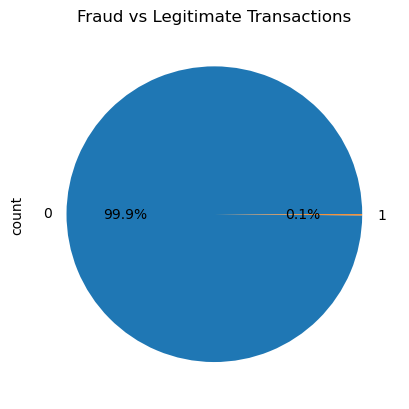

In [3]:
#Fraud Distribution Chart
import matplotlib.pyplot as plt

df['isFraud'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Fraud vs Legitimate Transactions')
plt.show()

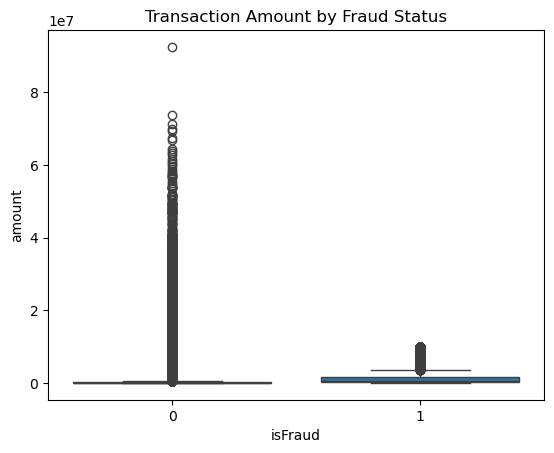

In [4]:
#Fraud Amount Analysis
import seaborn as sns

sns.boxplot(
    x='isFraud',
    y='amount',
    data=df
)

plt.title('Transaction Amount by Fraud Status')
plt.show()

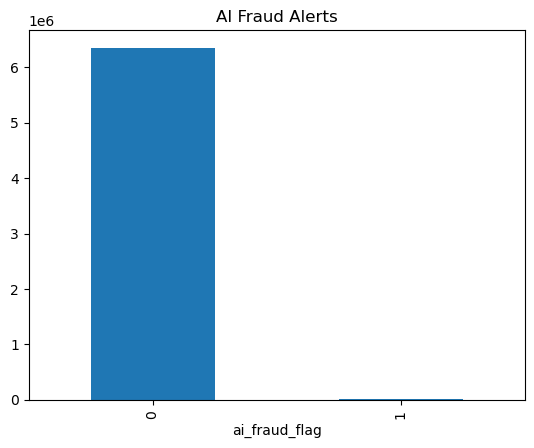

In [5]:
#AI Fraud Alerts
df['ai_fraud_flag'].value_counts().plot(
    kind='bar'
)

plt.title('AI Fraud Alerts')
plt.show()

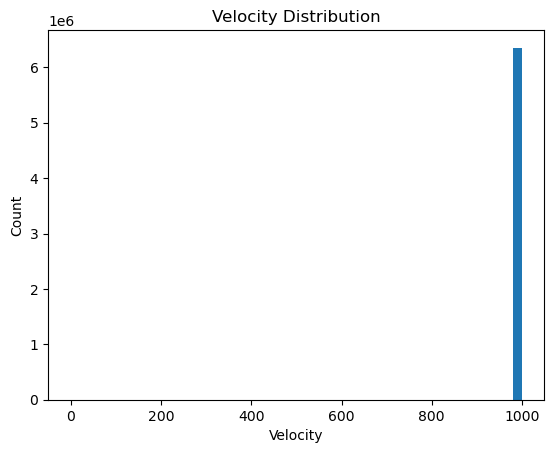

In [6]:
#Velocity Analysis
plt.hist(
    df['velocity'],
    bins=50
)

plt.title('Velocity Distribution')
plt.xlabel('Velocity')
plt.ylabel('Count')
plt.show()

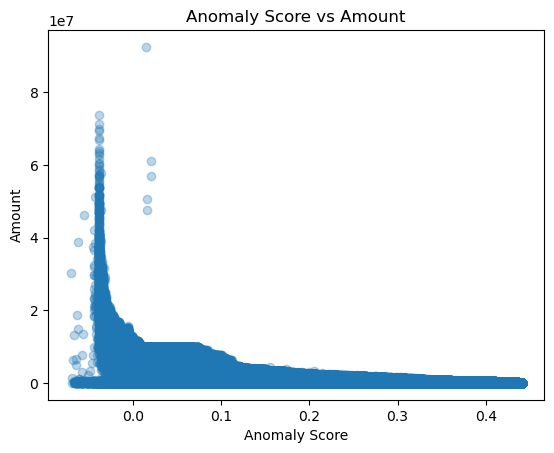

In [7]:
#Anomaly Score Analysis
plt.scatter(
    df['anomaly_score'],
    df['amount'],
    alpha=0.3
)

plt.xlabel('Anomaly Score')
plt.ylabel('Amount')
plt.title('Anomaly Score vs Amount')
plt.show()

In [8]:
#Top 20 Most Suspicious Transactions
df.sort_values(
    by='anomaly_score'
).head(20)

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,transaction_frequency,velocity,isFraud,ai_fraud_flag,anomaly_score
4337015,30305608.13,0.00,0.00,3.293943e+07,6.341088e+07,2,67.0,0,1,-0.070323
4757443,38560.15,28210765.39,28249325.54,8.845672e+07,8.841816e+07,1,999.0,0,1,-0.069202
1698548,1379094.53,22268807.63,23647902.16,6.990648e+07,6.852738e+07,1,999.0,0,1,-0.069202
3088660,6392504.36,0.00,0.00,5.053623e+07,5.692874e+07,2,25.0,0,1,-0.068082
4373029,434940.33,24527239.23,24962179.57,5.747612e+07,5.704118e+07,1,999.0,0,1,-0.066964
3326379,261708.74,24584414.64,24846123.38,2.362512e+08,2.359895e+08,1,999.0,0,1,-0.066964
2563069,13166481.83,0.00,0.00,3.456599e+07,4.773247e+07,2,284.0,0,1,-0.066406
4147618,96575.19,30160035.06,30256610.25,6.674909e+07,6.665251e+07,1,999.0,0,1,-0.066406
3339317,9757.68,27757042.28,27766799.96,3.574125e+07,3.573149e+07,1,999.0,0,1,-0.066406
3951560,6386.68,25363494.69,25369881.37,4.464659e+07,4.491860e+07,1,999.0,0,1,-0.065847


In [9]:
top20 = df.sort_values(
    by='anomaly_score'
).head(20)

top20.to_csv(
    'top20_suspicious_transactions.csv',
    index=False
)